# KIQ 3.3 — Volume and tone of privacy-related Reddit content over time

**Question:** How is privacy-related discussion of smart glasses framed (volume + tone) on Reddit, over time?

**Pipeline:** LLM (`gemma4-q6` via Ollama) judges whether each KIQ_3_3 item is
substantively about smart-glasses privacy and scores its sentiment.

**Caveats**
- Sample is broader than KIQ_3_2 (~2,300 items pre-filter), so percentages are more stable.
- Weekly buckets are still noisy on a small corpus; smooth visually, not statistically.

## Setup

In [1]:
import sys
from pathlib import Path

# Allow `import analysis_utils` and `import llm_utils` from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from analysis_utils import (
    BRAND_KEYWORDS,
    detect_brands,
    explode_brands,
    has_any_brand,
    sentiment_distribution,
    weekly_volume_and_sentiment,
    monthly_volume_and_sentiment,
)
from llm_utils import (
    score_dataframe_with_cache,
    smoke_test,
    DEFAULT_MODEL,
    KIQ_TOPICS,
)

POSTS_PATH = ROOT / "data" / "processed" / "reddit_posts_clean.csv"
COMMENTS_PATH = ROOT / "data" / "processed" / "reddit_comments_clean.csv"
CACHE_DIR = ROOT / "data" / "llm_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
OUT_DIR = ROOT / 'outputs' / 'kiq_3_3'
OUT_DIR.mkdir(parents=True, exist_ok=True)
KIQ = 'KIQ_3_3'

## Load and filter

In [3]:
posts = pd.read_csv(POSTS_PATH)
comments = pd.read_csv(COMMENTS_PATH)
posts['_llm_text'] = (
    posts['title'].fillna('').astype(str) + ' ' + posts['text'].fillna('').astype(str)
).str.strip()
comments['_llm_text'] = comments['body'].fillna('').astype(str)

posts_k = posts[(posts['kiq_label'] == KIQ) & (posts['_llm_text'].str.len() > 0)].copy()
comments_k = comments[(comments['kiq_label'] == KIQ) & (comments['_llm_text'].str.len() > 0)].copy()

print(f'Posts (KIQ_3_3):    {len(posts_k):>5}')
print(f'Comments (KIQ_3_3): {len(comments_k):>5}')
print(f'Estimated first-run LLM time at 4s/call: ~{(len(posts_k)+len(comments_k))*4/60:.0f} minutes')

Posts (KIQ_3_3):       65
Comments (KIQ_3_3):  2228
Estimated first-run LLM time at 4s/call: ~153 minutes


## LLM scoring (relevance + sentiment)

Each post and comment is sent to Ollama (`gemma4-q6:latest`, `think=false`).
The model returns `is_relevant`, `sentiment_label`, `sentiment_score`, and a brief `reason`.
Results are cached to `data/llm_cache/` by item id, so re-running this cell is instant after the first pass.

In [4]:
# Pre-flight: confirm Ollama + model are reachable BEFORE we start a long run.
import time
t0 = time.time()
_check = smoke_test()
print(f"Ollama OK ({DEFAULT_MODEL}) — single-call latency: {time.time()-t0:.1f}s")
print(f"  sample result: {_check}")


Ollama OK (gemma4-q6:latest) — single-call latency: 3.0s
  sample result: {'is_relevant': True, 'sentiment_label': 'negative', 'sentiment_score': -0.8, 'reason': "The comment directly discusses Meta's facial recognition feature and expresses strong negative concerns about privacy."}


In [5]:
posts_scored = score_dataframe_with_cache(
    posts_k,
    text_col='_llm_text',
    id_col='post_id',
    cache_path=CACHE_DIR / 'kiq_3_3_posts.csv',
    kiq='KIQ_3_3',
    kind='post',
)
comments_scored = score_dataframe_with_cache(
    comments_k,
    text_col='_llm_text',
    id_col='comment_id',
    cache_path=CACHE_DIR / 'kiq_3_3_comments.csv',
    kiq='KIQ_3_3',
    kind='comment',
)
posts_scored[['post_id', 'subreddit', 'is_relevant', 'sentiment_label', 'sentiment_score']].head()

[KIQ_3_3/post] cached: 0, to score: 65 of 65


KIQ_3_3/post: 100%|██████████| 65/65 [04:16<00:00,  3.95s/it]


[KIQ_3_3/comment] cached: 0, to score: 2228 of 2228


KIQ_3_3/comment: 100%|██████████| 2228/2228 [2:01:27<00:00,  3.27s/it]  


,post_id,subreddit,is_relevant,sentiment_label,sentiment_score
0,1khl1xh,privacy,True,negative,-0.8
1,1nldj4m,privacy,True,negative,-0.9
2,1r0iupy,privacy,True,negative,-0.8
3,1ntgzvn,augmentedreality,True,negative,-0.5
4,1sa2ofi,augmentedreality,True,negative,-0.9


## Apply LLM relevance filter

Drop items the model judged off-topic. The dropped sets are written to
`outputs/kiq_3_3/kiq_3_3_dropped_*.csv` for spot-checking.

In [6]:
posts_before = len(posts_scored); comments_before = len(comments_scored)
posts_dropped = posts_scored[posts_scored['is_relevant'] == False].copy()
comments_dropped = comments_scored[comments_scored['is_relevant'] == False].copy()
posts_scored = posts_scored[posts_scored['is_relevant'] == True].copy()
comments_scored = comments_scored[comments_scored['is_relevant'] == True].copy()

filter_log = pd.DataFrame([
    {'slice': 'posts',    'n_before': posts_before,    'n_after': len(posts_scored)},
    {'slice': 'comments', 'n_before': comments_before, 'n_after': len(comments_scored)},
])
print(f'Posts:    {posts_before:>5} -> {len(posts_scored):>5} after LLM relevance filter')
print(f'Comments: {comments_before:>5} -> {len(comments_scored):>5} after LLM relevance filter')
filter_log

Posts:       65 ->    50 after LLM relevance filter
Comments:  2228 ->   685 after LLM relevance filter


,slice,n_before,n_after
0,posts,65,50
1,comments,2228,685


## Weekly volume and tone

In [7]:
weekly_posts = weekly_volume_and_sentiment(posts_scored).rename(
    columns={'n': 'n_posts', 'mean_score': 'mean_score_posts'}
)[['week', 'n_posts', 'mean_score_posts']]
weekly_comments = weekly_volume_and_sentiment(comments_scored).rename(
    columns={'n': 'n_comments', 'mean_score': 'mean_score_comments'}
)[['week', 'n_comments', 'mean_score_comments']]
weekly = pd.merge(weekly_posts, weekly_comments, on='week', how='outer').sort_values('week')
weekly = weekly.fillna({'n_posts': 0, 'n_comments': 0})
weekly.head()

,week,n_posts,mean_score_posts,n_comments,mean_score_comments
0,2024-12-31,0.0,NaN,1.0,0.1
1,2025-03-11,1.0,0.6,0.0,NaN
2,2025-04-29,1.0,0.1,0.0,NaN
3,2025-05-06,1.0,-0.8,22.0,-0.681818
4,2025-05-20,1.0,-0.6,3.0,0.366667


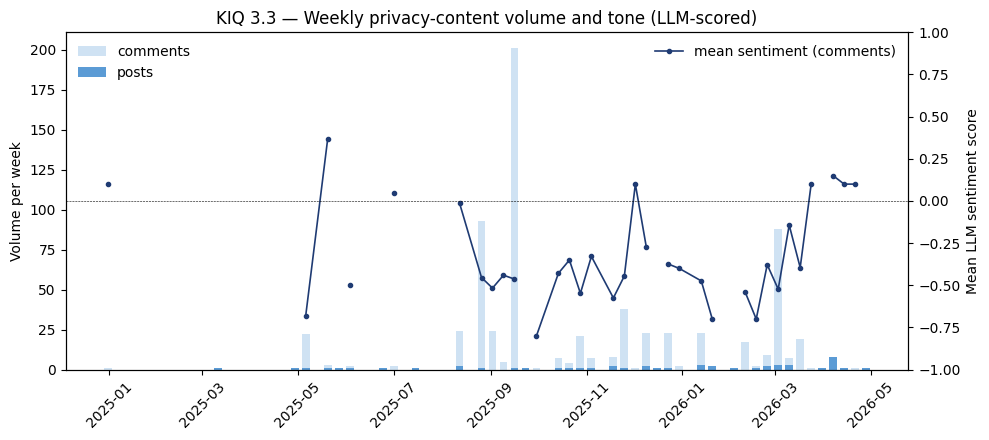

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 4.5), dpi=100)
ax1.bar(weekly['week'], weekly['n_comments'], width=5, color='#cfe2f3', label='comments')
ax1.bar(weekly['week'], weekly['n_posts'], width=5, color='#5b9bd5', label='posts')
ax1.set_ylabel('Volume per week')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper left', frameon=False)
ax2 = ax1.twinx()
ax2.plot(weekly['week'], weekly['mean_score_comments'], color='#1f3b73',
         marker='o', markersize=3, lw=1.2, label='mean sentiment (comments)')
ax2.axhline(0, color='black', lw=0.4, linestyle='--')
ax2.set_ylim(-1, 1)
ax2.set_ylabel('Mean LLM sentiment score')
ax2.legend(loc='upper right', frameon=False)
ax1.set_title('KIQ 3.3 — Weekly privacy-content volume and tone (LLM-scored)')
fig.tight_layout()
fig.savefig(OUT_DIR / 'kiq_3_3_volume_tone.png', dpi=300)
plt.show()

## Subreddit breakdown

In [10]:
combined = pd.concat([
    posts_scored.assign(_kind='post')[['subreddit', 'sentiment_score', '_kind']],
    comments_scored.assign(_kind='comment')[['subreddit', 'sentiment_score', '_kind']],
], ignore_index=True)
sub_counts = combined['subreddit'].value_counts().head(10)
sub_counts

subreddit
privacy             269
technology          247
Futurology           78
augmentedreality     68
RaybanMeta           48
SmartGlasses         11
Xreal                 9
Android               3
gadgets               1
technews              1
Name: count, dtype: int64

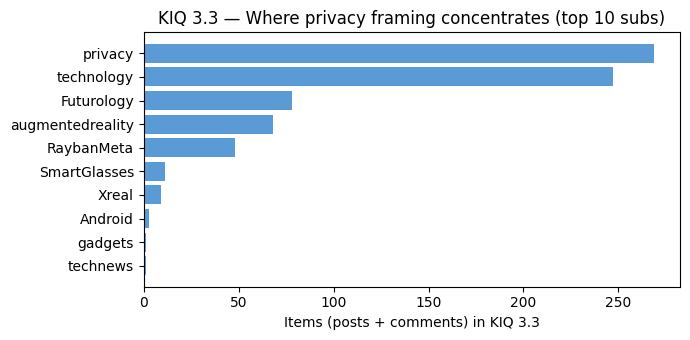

In [11]:
fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * len(sub_counts))), dpi=100)
ax.barh(sub_counts.index[::-1], sub_counts.values[::-1], color='#5b9bd5')
ax.set_xlabel('Items (posts + comments) in KIQ 3.3')
ax.set_title('KIQ 3.3 — Where privacy framing concentrates (top 10 subs)')
fig.tight_layout()
fig.savefig(OUT_DIR / 'kiq_3_3_by_subreddit.png', dpi=300)
plt.show()

## Sentiment label distribution

In [12]:
dist_posts = sentiment_distribution(posts_scored)
dist_comments = sentiment_distribution(comments_scored)
dist_df = pd.DataFrame({'posts': dist_posts, 'comments': dist_comments})
dist_pct = (dist_df / dist_df.sum()) * 100
dist_pct.round(1)

,posts,comments
sentiment_label,,
positive,24.0,4.7
neutral,22.0,17.5
negative,54.0,77.8


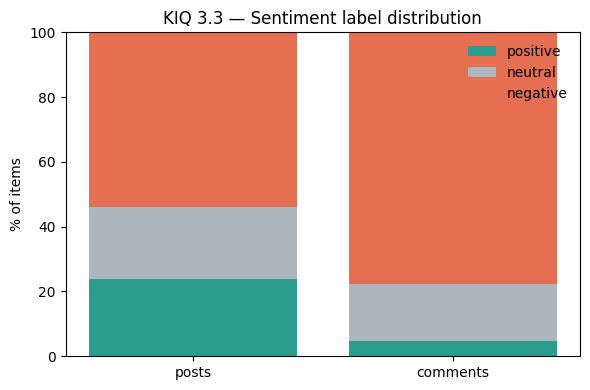

In [13]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=100)
colors = {'positive': '#2a9d8f', 'neutral': '#adb5bd', 'negative': '#e76f51'}
x = list(range(len(dist_pct.columns)))
bottom = [0] * len(dist_pct.columns)
for label in ['positive', 'neutral', 'negative']:
    vals = dist_pct.loc[label].values
    ax.bar(x, vals, bottom=bottom, label=label, color=colors[label])
    bottom = [b + v for b, v in zip(bottom, vals)]
ax.set_xticks(x); ax.set_xticklabels(dist_pct.columns)
ax.set_ylim(0, 100); ax.set_ylabel('% of items')
ax.set_title('KIQ 3.3 — Sentiment label distribution')
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / 'kiq_3_3_distribution.png', dpi=300)
plt.show()

## Write outputs

In [15]:
posts_scored.to_csv(OUT_DIR / 'kiq_3_3_scored_posts.csv', index=False)
comments_scored.to_csv(OUT_DIR / 'kiq_3_3_scored_comments.csv', index=False)
weekly.to_csv(OUT_DIR / 'kiq_3_3_timeseries.csv', index=False)
sub_counts.rename('n').to_frame().to_csv(OUT_DIR / 'kiq_3_3_by_subreddit.csv')
dist_pct.to_csv(OUT_DIR / 'kiq_3_3_distribution.csv')
filter_log.to_csv(OUT_DIR / 'kiq_3_3_filter_log.csv', index=False)
posts_dropped.to_csv(OUT_DIR / 'kiq_3_3_dropped_posts.csv', index=False)
comments_dropped.to_csv(OUT_DIR / 'kiq_3_3_dropped_comments.csv', index=False)

print('Wrote outputs to', OUT_DIR)
for f in sorted(OUT_DIR.iterdir()):
    print(' -', f.name)

Wrote outputs to /home/giulio/Uni/Master/SCI/outputs/kiq_3_3
 - kiq_3_3_by_subreddit.csv
 - kiq_3_3_by_subreddit.png
 - kiq_3_3_distribution.csv
 - kiq_3_3_distribution.png
 - kiq_3_3_dropped_comments.csv
 - kiq_3_3_dropped_posts.csv
 - kiq_3_3_filter_log.csv
 - kiq_3_3_scored_comments.csv
 - kiq_3_3_scored_posts.csv
 - kiq_3_3_timeseries.csv
 - kiq_3_3_volume_tone.png
